# Analisis de mascaras de celulas

Este notebook compara mascaras de celulas que parecen buenas contra una mascara problematica. La idea es medir area y forma de cada objeto para entender por que algunos fragmentos pasan el filtro actual de area minima.

No modifica el pipeline ni las mascaras originales. Solo calcula tablas, graficos y una simulacion de filtros candidatos.

In [5]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tifffile
from IPython.display import display
from skimage.color import label2rgb
from skimage.measure import regionprops_table

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "0001__Snap-12879").exists() and (PROJECT_ROOT.parent / "0001__Snap-12879").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

# Mascaras que visualmente tomamos como referencia buena.
GOOD_IMAGE_IDS = ["Snap-12879", "Snap-12885", "Snap-12899"]

# Mascara con fragmentacion/falsos positivos finos.
PROBLEM_IMAGE_IDS = ["Snap-12907"]

# Carpeta raiz donde estan las carpetas 0001__Snap-.../cell_mask.tiff.
MASK_ROOT = PROJECT_ROOT

OUTPUT_DIR = PROJECT_ROOT / "analisis_mascaras_celulas_salida"
OUTPUT_DIR.mkdir(exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("MASK_ROOT:", MASK_ROOT)
print("OUTPUT_DIR:", OUTPUT_DIR)

PROJECT_ROOT: c:\Users\naiar\OneDrive\Escritorio\Unsam\ciencia-de-datos\proyecto
MASK_ROOT: c:\Users\naiar\OneDrive\Escritorio\Unsam\ciencia-de-datos\proyecto
OUTPUT_DIR: c:\Users\naiar\OneDrive\Escritorio\Unsam\ciencia-de-datos\proyecto\analisis_mascaras_celulas_salida


## Carga y medicion

Cada objeto de `cell_mask.tiff` se trata como una celula/fragmento. Calculamos area y medidas de forma: grosor aproximado, elongacion, solidez, excentricidad y si toca el borde.

In [6]:
def find_cell_mask(image_id, root=MASK_ROOT):
    root = Path(root)
    hits = sorted(root.rglob(f"*{image_id}*/cell_mask.tiff"))
    if not hits:
        hits = sorted(root.rglob(f"*{image_id}*cell_mask*.tif*"))
    if not hits:
        raise FileNotFoundError(f"No encontre cell_mask.tiff para {image_id} bajo {root}")
    return hits[0]


def load_label_mask(path):
    arr = tifffile.imread(str(path))
    arr = np.squeeze(arr)
    while arr.ndim > 2:
        arr = arr[0]
    return arr.astype(np.int32, copy=False)


def measure_cells(image_id, group, mask_root=MASK_ROOT):
    mask_path = find_cell_mask(image_id, mask_root)
    labels = load_label_mask(mask_path)

    props = regionprops_table(
        labels,
        properties=(
            "label",
            "area",
            "bbox",
            "bbox_area",
            "convex_area",
            "eccentricity",
            "extent",
            "major_axis_length",
            "minor_axis_length",
            "perimeter",
            "solidity",
        ),
    )
    df = pd.DataFrame(props)
    if df.empty:
        return df

    height, width = labels.shape
    df.insert(0, "image_id", image_id)
    df.insert(1, "group", group)
    df["mask_path"] = str(mask_path)
    df["image_height"] = height
    df["image_width"] = width

    minor = df["minor_axis_length"].replace(0, np.nan)
    df["elongation"] = (df["major_axis_length"] / minor).replace([np.inf, -np.inf], np.nan)
    df["compactness"] = (4 * np.pi * df["area"] / (df["perimeter"] ** 2)).replace([np.inf, -np.inf], np.nan)
    df["touches_border"] = (
        (df["bbox-0"] <= 0)
        | (df["bbox-1"] <= 0)
        | (df["bbox-2"] >= height)
        | (df["bbox-3"] >= width)
    )
    return df


rows = []
for image_id in GOOD_IMAGE_IDS:
    rows.append(measure_cells(image_id, group="buena"))
for image_id in PROBLEM_IMAGE_IDS:
    rows.append(measure_cells(image_id, group="problematica"))

df_cells = pd.concat(rows, ignore_index=True)
df_cells = df_cells.round(2)
df_cells.to_csv(OUTPUT_DIR / "propiedades_celulas_por_objeto.csv", index=False, sep=";")

print(f"Objetos medidos: {len(df_cells)}")
display(df_cells.head(20))


Objetos medidos: 29


,image_id,group,label,area,bbox-0,bbox-1,bbox-2,bbox-3,bbox_area,convex_area,...,major_axis_length,minor_axis_length,perimeter,solidity,mask_path,image_height,image_width,elongation,compactness,touches_border
0,Snap-12879,buena,1,31462.0,163,333,341,559,40228.0,31754.0,...,225.20,178.09,668.34,0.99,c:\Users\naiar\OneDrive\Escritorio\Unsam\cienc...,1080,1920,1.26,0.89,False
1,Snap-12879,buena,2,25544.0,633,818,820,1011,36091.0,26380.0,...,217.65,152.07,623.03,0.97,c:\Users\naiar\OneDrive\Escritorio\Unsam\cienc...,1080,1920,1.43,0.83,False
2,Snap-12879,buena,3,20762.0,811,388,968,565,27789.0,21286.0,...,178.45,150.15,562.46,0.98,c:\Users\naiar\OneDrive\Escritorio\Unsam\cienc...,1080,1920,1.19,0.82,False
3,Snap-12879,buena,4,18070.0,885,1114,1043,1260,23068.0,18310.0,...,164.39,140.45,511.35,0.99,c:\Users\naiar\OneDrive\Escritorio\Unsam\cienc...,1080,1920,1.17,0.87,False
4,Snap-12879,buena,5,3240.0,1012,1851,1080,1920,4692.0,3271.0,...,81.94,55.17,237.78,0.99,c:\Users\naiar\OneDrive\Escritorio\Unsam\cienc...,1080,1920,1.49,0.72,True
5,Snap-12885,buena,1,11487.0,442,330,553,463,14763.0,11595.0,...,135.35,108.13,401.40,0.99,c:\Users\naiar\OneDrive\Escritorio\Unsam\cienc...,1080,1920,1.25,0.90,False
6,Snap-12885,buena,2,14480.0,492,476,618,611,17010.0,14611.0,...,142.08,130.47,450.05,0.99,c:\Users\naiar\OneDrive\Escritorio\Unsam\cienc...,1080,1920,1.09,0.90,False
7,Snap-12885,buena,3,12254.0,612,270,735,395,15375.0,12378.0,...,127.10,122.98,412.92,0.99,c:\Users\naiar\OneDrive\Escritorio\Unsam\cienc...,1080,1920,1.03,0.90,False
8,Snap-12885,buena,4,11174.0,640,427,754,549,13908.0,11301.0,...,131.41,108.82,397.71,0.99,c:\Users\naiar\OneDrive\Escritorio\Unsam\cienc...,1080,1920,1.21,0.89,False
9,Snap-12899,buena,1,16352.0,0,759,140,910,21140.0,16502.0,...,156.79,139.99,507.95,0.99,c:\Users\naiar\OneDrive\Escritorio\Unsam\cienc...,1080,1920,1.12,0.80,True


## Resumen por imagen y por grupo

Aca miramos percentiles. Los percentiles de las mascaras buenas sirven como referencia para elegir umbrales sin hacerlo completamente a ojo.

In [7]:
FEATURES = [
    "area",
    "minor_axis_length",
    "major_axis_length",
    "elongation",
    "eccentricity",
    "solidity",
    "extent",
    "compactness",
]


def percentile_summary(df, by):
    qs = [0.0, 0.1, 0.25, 0.5, 0.75, 0.9, 1.0]
    pieces = []
    for key, part in df.groupby(by):
        q = part[FEATURES].quantile(qs).round(2)
        q.insert(0, by, key)
        q.insert(1, "percentil", ["min", "p10", "p25", "p50", "p75", "p90", "max"])
        pieces.append(q.reset_index(drop=True))
    return pd.concat(pieces, ignore_index=True)


resumen_imagen = percentile_summary(df_cells, "image_id")
resumen_grupo = percentile_summary(df_cells, "group")

conteos = df_cells.groupby(["group", "image_id"]).agg(
    objetos=("label", "count"),
    area_mediana=("area", "median"),
    area_min=("area", "min"),
    area_max=("area", "max"),
    minor_axis_mediana=("minor_axis_length", "median"),
    elongation_mediana=("elongation", "median"),
    objetos_borde=("touches_border", "sum"),
).round(2).reset_index()

resumen_imagen.to_csv(OUTPUT_DIR / "resumen_percentiles_por_imagen.csv", index=False, sep=";")
resumen_grupo.to_csv(OUTPUT_DIR / "resumen_percentiles_por_grupo.csv", index=False, sep=";")
conteos.to_csv(OUTPUT_DIR / "resumen_conteos_por_imagen.csv", index=False, sep=";")

print("Conteos por imagen")
display(conteos)

print("Percentiles por grupo")
display(resumen_grupo)

print("Percentiles por imagen")
display(resumen_imagen)


Conteos por imagen


,group,image_id,objetos,area_mediana,area_min,area_max,minor_axis_mediana,elongation_mediana,objetos_borde
0,buena,Snap-12879,5,20762.0,3240.0,31462.0,150.15,1.26,1
1,buena,Snap-12885,4,11870.5,11174.0,14480.0,115.90,1.15,0
2,buena,Snap-12899,10,19717.5,16352.0,35683.0,144.05,1.23,2
3,problematica,Snap-12907,10,1132.0,727.0,26322.0,29.71,2.24,0


Percentiles por grupo


,group,percentil,area,minor_axis_length,major_axis_length,elongation,eccentricity,solidity,extent,compactness
0,buena,min,3240.00,55.17,81.94,1.03,0.25,0.97,0.69,0.72
1,buena,p10,11424.40,108.68,130.55,1.08,0.37,0.99,0.74,0.79
2,buena,p25,15416.00,126.72,145.15,1.15,0.49,0.99,0.76,0.84
3,buena,p50,18070.00,140.45,176.48,1.22,0.57,0.99,0.77,0.87
4,buena,p75,25822.50,158.12,209.28,1.31,0.64,0.99,0.78,0.90
5,buena,p90,31149.20,173.03,225.40,1.44,0.72,0.99,0.80,0.90
6,buena,max,35683.00,201.00,231.02,1.65,0.80,0.99,0.85,0.90
7,problematica,min,727.00,12.91,45.41,1.22,0.57,0.65,0.21,0.12
8,problematica,p10,736.00,14.86,47.15,1.44,0.71,0.70,0.28,0.24
9,problematica,p25,937.50,20.68,65.05,1.61,0.77,0.82,0.38,0.33


Percentiles por imagen


,image_id,percentil,area,minor_axis_length,major_axis_length,elongation,eccentricity,solidity,extent,compactness
0,Snap-12879,min,3240.00,55.17,81.94,1.17,0.52,0.97,0.69,0.72
1,Snap-12879,p10,9172.00,89.28,114.92,1.18,0.53,0.97,0.70,0.76
2,Snap-12879,p25,18070.00,140.45,164.39,1.19,0.54,0.98,0.71,0.82
3,Snap-12879,p50,20762.00,150.15,178.45,1.26,0.61,0.99,0.75,0.83
4,Snap-12879,p75,25544.00,152.07,217.65,1.43,0.72,0.99,0.78,0.87
5,Snap-12879,p90,29094.80,167.68,222.18,1.47,0.73,0.99,0.78,0.88
6,Snap-12879,max,31462.00,178.09,225.20,1.49,0.74,0.99,0.78,0.89
7,Snap-12885,min,11174.00,108.13,127.10,1.03,0.25,0.99,0.78,0.89
8,Snap-12885,p10,11267.90,108.34,128.39,1.05,0.30,0.99,0.79,0.89
9,Snap-12885,p25,11408.75,108.65,130.33,1.08,0.36,0.99,0.80,0.90


## Graficos rapidos

Estos graficos ayudan a ver si los fragmentos problematicos se separan por area, grosor (`minor_axis_length`) o elongacion.

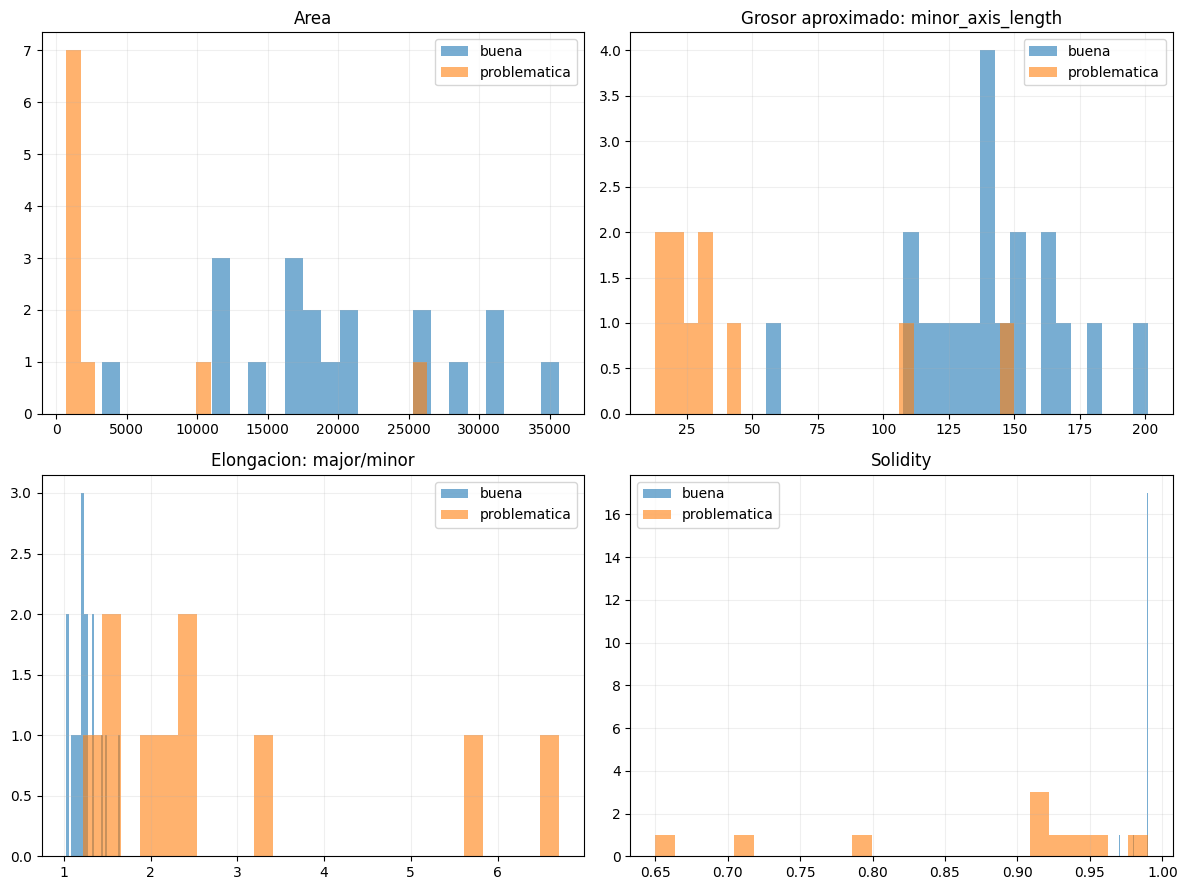

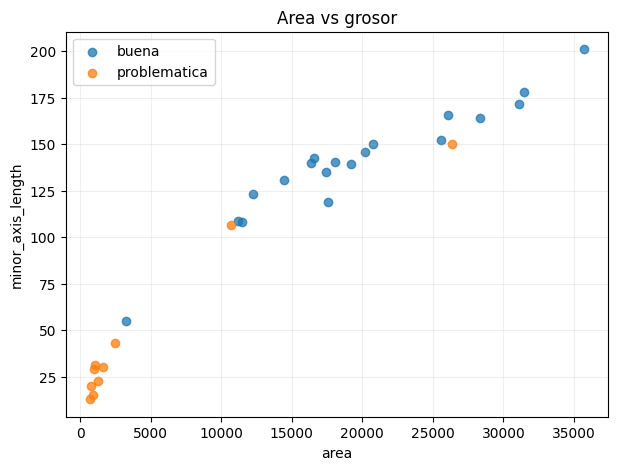

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

for group, part in df_cells.groupby("group"):
    axes[0, 0].hist(part["area"], bins=25, alpha=0.6, label=group)
    axes[0, 1].hist(part["minor_axis_length"], bins=25, alpha=0.6, label=group)
    axes[1, 0].hist(part["elongation"].dropna(), bins=25, alpha=0.6, label=group)
    axes[1, 1].hist(part["solidity"].dropna(), bins=25, alpha=0.6, label=group)

axes[0, 0].set_title("Area")
axes[0, 1].set_title("Grosor aproximado: minor_axis_length")
axes[1, 0].set_title("Elongacion: major/minor")
axes[1, 1].set_title("Solidity")

for ax in axes.ravel():
    ax.legend()
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
for group, part in df_cells.groupby("group"):
    ax.scatter(part["area"], part["minor_axis_length"], alpha=0.75, label=group)
ax.set_xlabel("area")
ax.set_ylabel("minor_axis_length")
ax.set_title("Area vs grosor")
ax.grid(alpha=0.2)
ax.legend()
plt.show()


## Probar filtros candidatos

Estos umbrales son para explorar. La idea es ver que eliminaria cada regla antes de llevar algo al pipeline.

- `AREA_MIN`: filtro actual aproximado.
- `MIN_MINOR_AXIS`: elimina objetos demasiado finos.
- `MAX_ELONGATION`: elimina objetos muy alargados.
- `MIN_SOLIDITY`: elimina objetos poco compactos.
- `BORDER_SMALL_AREA_MAX`: elimina objetos chicos que ademas tocan borde.

In [14]:
AREA_MIN = 2500
MAX_ELONGATION = 2

df_filter = df_cells.copy()
df_filter["flag_area_chica"] = df_filter["area"] < AREA_MIN
df_filter["flag_muy_alargada"] = df_filter["elongation"] > MAX_ELONGATION

flag_cols = [
    "flag_area_chica",
    "flag_muy_alargada",
]
df_filter["descartar_candidato"] = df_filter[flag_cols].any(axis=1)

resumen_filtro = df_filter.groupby(["group", "image_id"]).agg(
    objetos_total=("label", "count"),
    descartaria=("descartar_candidato", "sum"),
    conservaria=("descartar_candidato", lambda s: int((~s).sum())),
).reset_index()

df_filter.to_csv(OUTPUT_DIR / "objetos_con_flags_filtro.csv", index=False, sep=";")
resumen_filtro.to_csv(OUTPUT_DIR / "resumen_filtro_candidato.csv", index=False, sep=";")

print("Resumen del filtro candidato")
display(resumen_filtro)

print("Objetos que descartaria, ordenados por imagen y area")
cols = ["image_id", "group", "label", "area", "minor_axis_length", "elongation", "solidity", "touches_border"] + flag_cols
display(df_filter[df_filter["descartar_candidato"]][cols].sort_values(["image_id", "area"]))


Resumen del filtro candidato


,group,image_id,objetos_total,descartaria,conservaria
0,buena,Snap-12879,5,0,5
1,buena,Snap-12885,4,0,4
2,buena,Snap-12899,10,0,10
3,problematica,Snap-12907,10,8,2


Objetos que descartaria, ordenados por imagen y area


,image_id,group,label,area,minor_axis_length,elongation,solidity,touches_border,flag_area_chica,flag_muy_alargada
24,Snap-12907,problematica,6,727.0,12.91,6.71,0.71,False,True,True
28,Snap-12907,problematica,10,737.0,20.03,2.36,0.96,False,True,True
26,Snap-12907,problematica,8,916.0,15.08,5.67,0.79,False,True,True
19,Snap-12907,problematica,1,1002.0,29.23,2.12,0.65,False,True,True
20,Snap-12907,problematica,2,1022.0,31.06,1.46,0.91,False,True,False
21,Snap-12907,problematica,3,1242.0,22.62,3.27,0.91,False,True,True
23,Snap-12907,problematica,5,1610.0,30.19,2.51,0.94,False,True,True
25,Snap-12907,problematica,7,2497.0,42.92,1.98,0.92,False,True,False


## Visualizar objetos descartados

Rojo = objetos que el filtro candidato descartaria. Gris = objetos que conservaria.

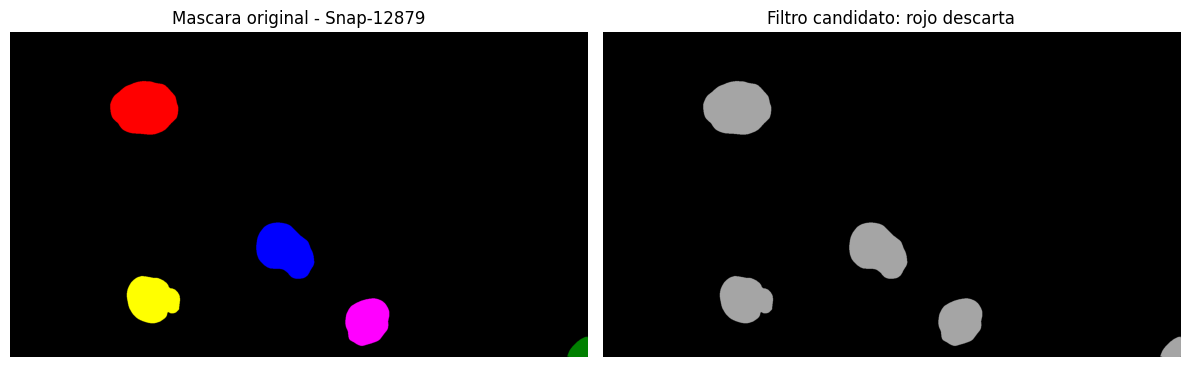

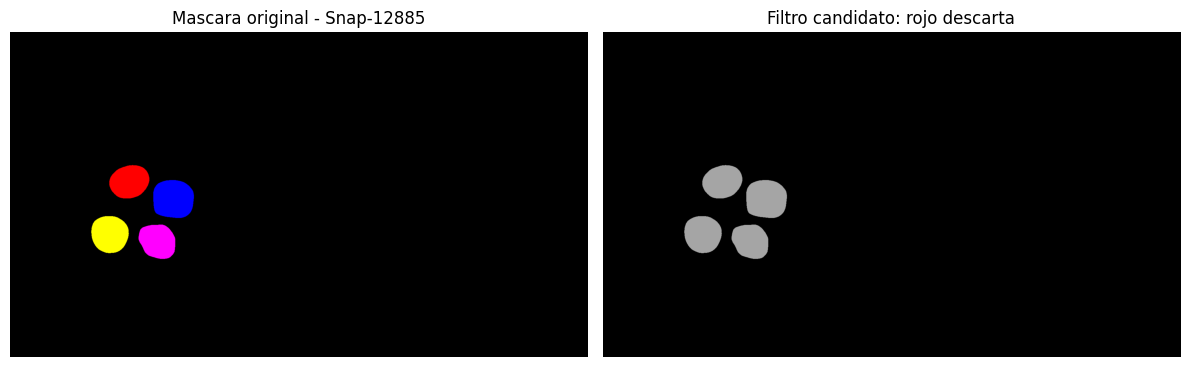

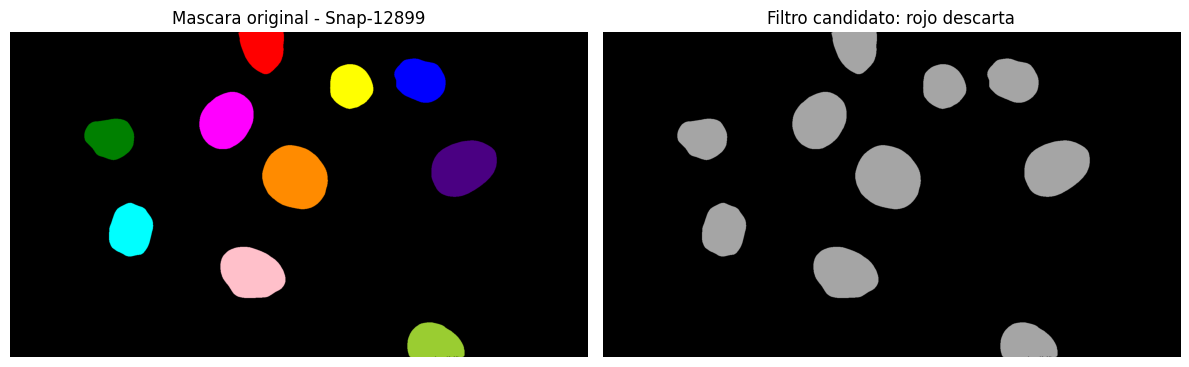

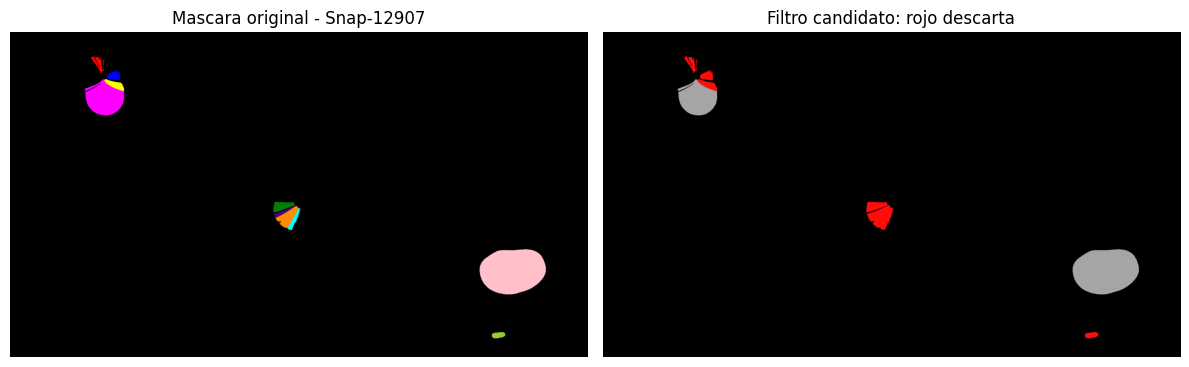

In [15]:
def plot_filter_candidate(image_id):
    mask_path = find_cell_mask(image_id)
    labels = load_label_mask(mask_path)
    part = df_filter[df_filter["image_id"] == image_id]
    discard_ids = set(part.loc[part["descartar_candidato"], "label"].astype(int))

    keep_mask = np.isin(labels, list(set(part["label"].astype(int)) - discard_ids))
    discard_mask = np.isin(labels, list(discard_ids))

    rgb = np.zeros((*labels.shape, 3), dtype=float)
    rgb[keep_mask] = [0.65, 0.65, 0.65]
    rgb[discard_mask] = [1.0, 0.05, 0.05]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(label2rgb(labels, bg_label=0))
    axes[0].set_title(f"Mascara original - {image_id}")
    axes[1].imshow(rgb)
    axes[1].set_title("Filtro candidato: rojo descarta")
    for ax in axes:
        ax.axis("off")
    plt.tight_layout()
    plt.show()


for image_id in GOOD_IMAGE_IDS + PROBLEM_IMAGE_IDS:
    plot_filter_candidate(image_id)


## Lectura sugerida

Para decidir un filtro, mirar primero:

1. Si en la imagen problematica aparecen objetos con `minor_axis_length` mucho menor que en las buenas.
2. Si esos objetos tambien tienen `elongation` muy alta.
3. Si el filtro candidato elimina muchos objetos de las buenas. Si elimina muchos, esta demasiado agresivo.
4. Si los objetos rojos en la visualizacion coinciden con fragmentos finos/no celulares.